# 1. EDA
- Load data
- Explore data (5 line)
- Data visualization (Charts)

In [80]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('heart_disease_uci.csv')

print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

Dataset has 920 rows and 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [82]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Age - Num 


Text(0.5, 1.0, 'Age distribution')

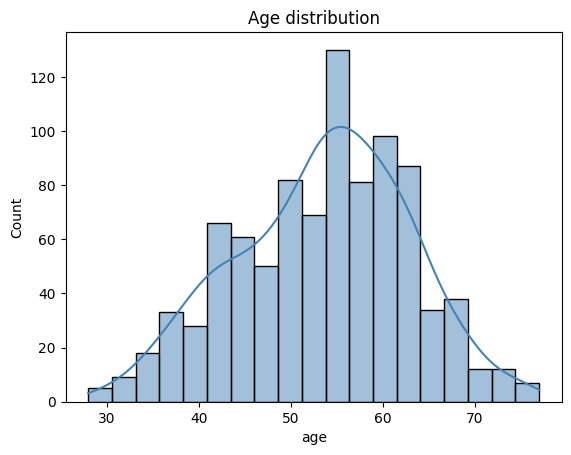

In [83]:
import seaborn as sns
sns.histplot(df['age'], kde=True, color='steelblue')
plt.title('Age distribution')

### Gender - Cat


sex
Male      726
Female    194
Name: count, dtype: int64
Male is almost 3.5 times more than female in this dataset


Text(0.5, 1.0, 'Gender counts')

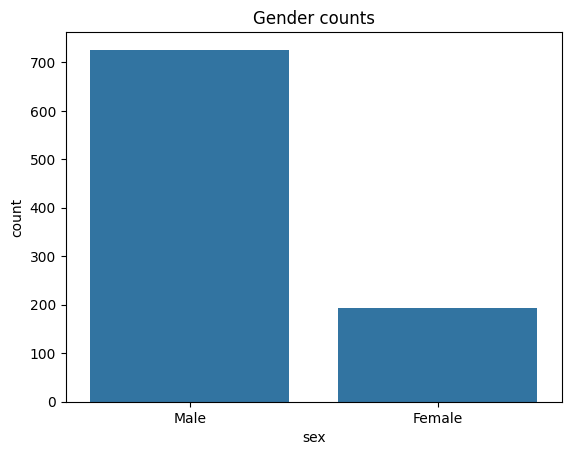

In [84]:
print(df['sex'].value_counts())
print("Male is almost 3.5 times more than female in this dataset")

sns.countplot(df, x='sex')
plt.title('Gender counts')


### Dataset location - Cat

<StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str


Text(0.5, 1.0, 'Dataset location Distribution')

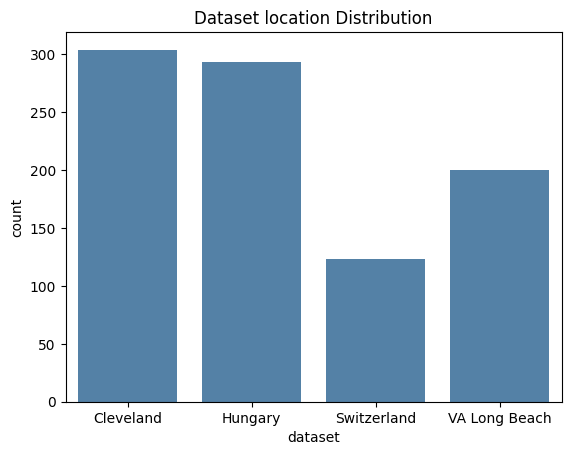

In [85]:
print(df['dataset'].unique())
sns.countplot(df, x='dataset', color='steelblue' )
plt.title('Dataset location Distribution')

### CP (chest pain type) - Cat

<StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str


Text(0.5, 1.0, 'Chest pain type Distribution')

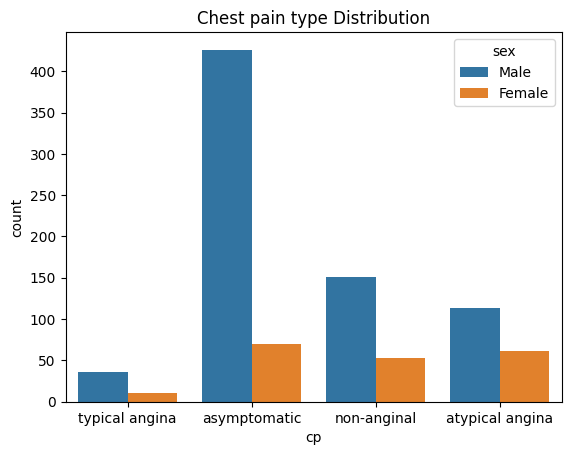

In [86]:
print(df['cp'].unique())
sns.countplot(df, x='cp', hue='sex' )
plt.title('Chest pain type Distribution')

### trestbps (resting blood pressure) - Num

mean: 132.13240418118468


Text(0.5, 1.0, 'boxplot')

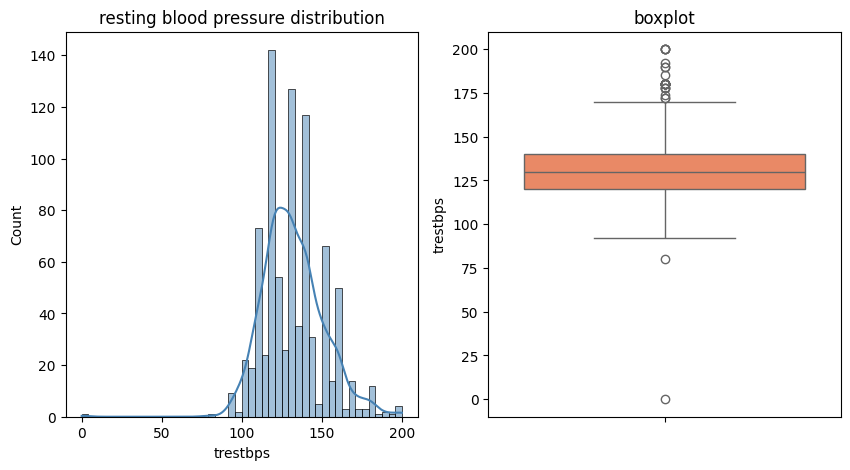

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['trestbps'], color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('resting blood pressure distribution')
print(f'mean: {df['trestbps'].mean()}')

sns.boxplot(df['trestbps'], color='coral', ax=axes[1])
axes[1].set_title('boxplot')

In [88]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print(df[df['trestbps']<80]['trestbps'].count())
print(df[df['trestbps']>175]['trestbps'].count())
print(f'Percentage of missing values in trestbps column: {df['trestbps'].isnull().sum() / len(df) * 100:.2f}%')

# remove outliers for low trestbps
df = df[(df['trestbps']>=80)  | (df['trestbps'].isna())]
print(len(df['trestbps']))
# Remove 6.4% missing values
imputer1 = IterativeImputer(max_iter=10, random_state=42)
imputer1.fit(df[['trestbps']])
df['trestbps'] = imputer1.transform(df[['trestbps']])
print(f"Missing values in trestbps column: {df['trestbps'].isnull().sum()}")
df.info()

1
23
Percentage of missing values in trestbps column: 6.41%
919
Missing values in trestbps column: 0
<class 'pandas.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    str    
 3   dataset   919 non-null    str    
 4   cp        919 non-null    str    
 5   trestbps  919 non-null    float64
 6   chol      889 non-null    float64
 7   fbs       829 non-null    object 
 8   restecg   917 non-null    str    
 9   thalch    864 non-null    float64
 10  exang     864 non-null    object 
 11  oldpeak   857 non-null    float64
 12  slope     610 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       919 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 122.1+ KB


### Chol (serum cholesterol in mg/dl) - Num

mean: 199.35433070866142
there are around 170 of people whose chol is 0, which certainly are missing values encoded as 0


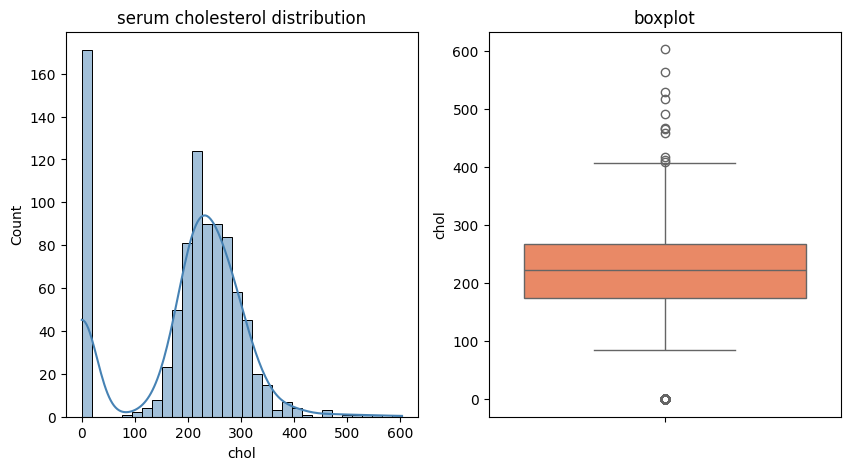

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['chol'], color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('serum cholesterol distribution')
print(f'mean: {df['chol'].mean()}')

sns.boxplot(df['chol'], color='coral', ax=axes[1])
axes[1].set_title('boxplot')
print('there are around 170 of people whose chol is 0, which certainly are missing values encoded as 0')

In [90]:
# Handle outlier and missing values
print(len(df[df['chol']==0]))
# replace 0 with NaN
df['chol'] = df['chol'].replace(0, np.nan)
print(f'Percentage of missing chol values is: {df['chol'].isnull().sum() / len(df['chol']) * 100:.2f}%')

171
Percentage of missing chol values is: 21.87%


In [91]:
# With 20% missing and roughly normal (slight right skew), best options:
# IterativeImputer (recommended) — uses relationships between columns, handles skew well:
num_cols_missing = ['chol']

### fbs (if fasting blood sugar > 120 mg/dl) - Cat (bool)

[True False nan]
Percentage of missing fbs values is: 9.79%


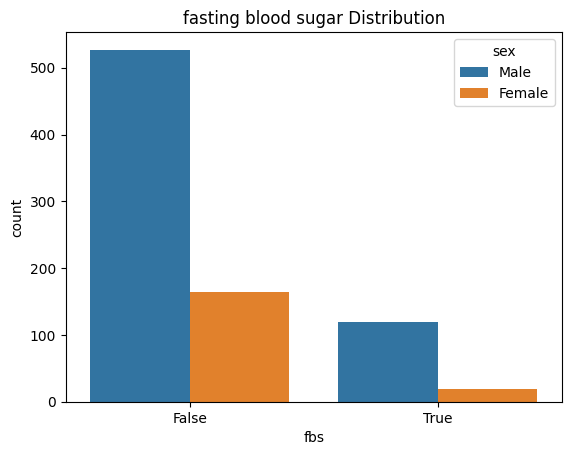

In [92]:
print(df['fbs'].unique())
sns.countplot(df, x='fbs', hue='sex' )
plt.title('fasting blood sugar Distribution')

print(f'Percentage of missing fbs values is: {df['fbs'].isnull().sum() / len(df['fbs']) * 100:.2f}%')

<StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str


Text(0.5, 1.0, 'Chest pain type Distribution')

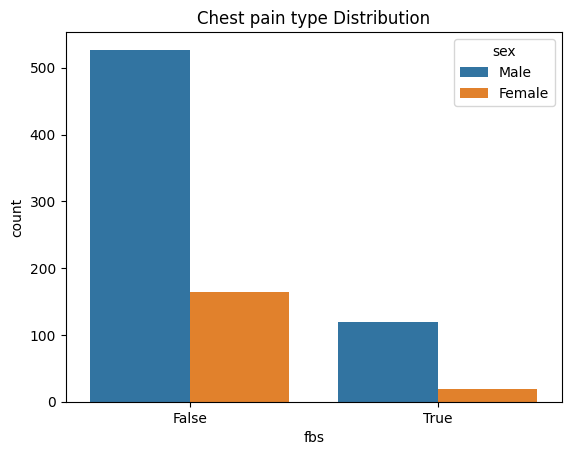

In [93]:
print(df['cp'].unique())
sns.countplot(df, x='fbs', hue='sex' )
plt.title('Chest pain type Distribution')

### restecg (resting electrocardiographic results) - Cat

<StringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
missing restecg count: 2
Percentage of missing restecg values is: 0.22%


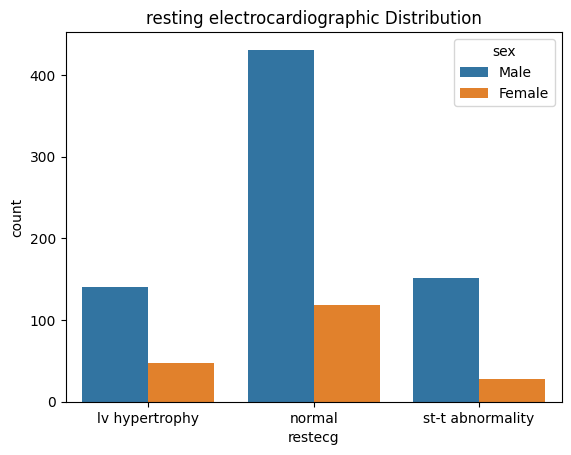

In [94]:
print(df['restecg'].unique())
sns.countplot(df, x='restecg', hue='sex' )
plt.title('resting electrocardiographic Distribution')
print(f'missing restecg count: {df['restecg'].isnull().sum()}')
print(f'Percentage of missing restecg values is: {df['restecg'].isnull().sum() / len(df['restecg']) * 100:.2f}%')

### thalch (maximum heart rate achieved) - Num

mean: 137.52546296296296
distribution looks close to normal distribution. No obvious outliers
missing thalch count: 55
Percentage of missing thalch values is: 5.98%


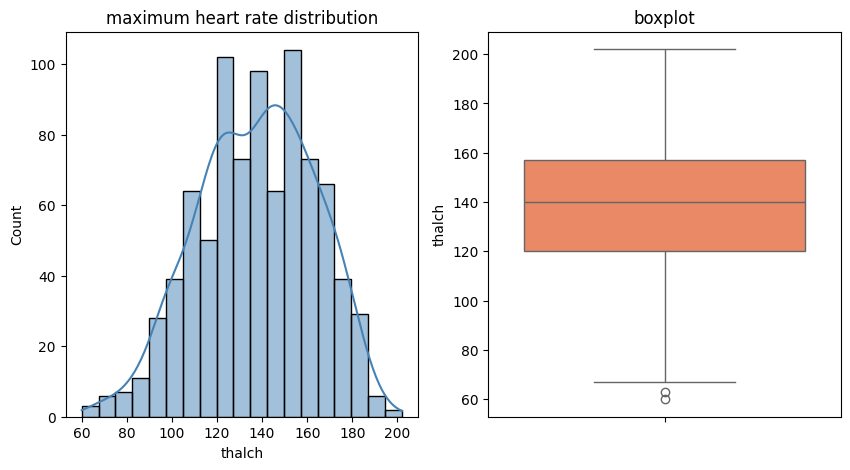

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['thalch'], color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('maximum heart rate distribution')
print(f'mean: {df['thalch'].mean()}')

sns.boxplot(df['thalch'], color='coral', ax=axes[1])
axes[1].set_title('boxplot')
print('distribution looks close to normal distribution. No obvious outliers')

print(f'missing thalch count: {df['thalch'].isnull().sum()}')
print(f'Percentage of missing thalch values is: {df['thalch'].isnull().sum() / len(df['thalch']) * 100:.2f}%')



### exang (exercise-induced angina) - Cat (bool)

[False True nan]
missing exang count: 55
Percentage of missing exang values is: 5.98%


Text(0.5, 1.0, 'exang Distribution')

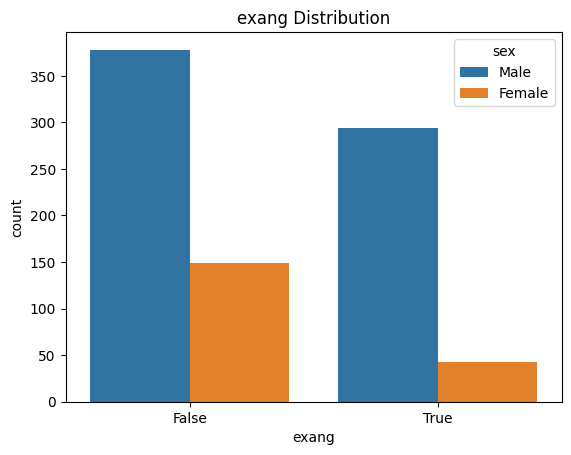

In [96]:
print(df['exang'].unique())
print(f'missing exang count: {df['exang'].isnull().sum()}')
print(f'Percentage of missing exang values is: {df['exang'].isnull().sum() / len(df['exang']) * 100:.2f}%')

sns.countplot(df, x='exang', hue='sex' )
plt.title('exang Distribution')


### oldpeak: ST depression induced by exercise relative to rest - Num

mean: 0.8780630105017503
missing oldpeak count: 62
Percentage of missing oldpeak values is: 6.75%


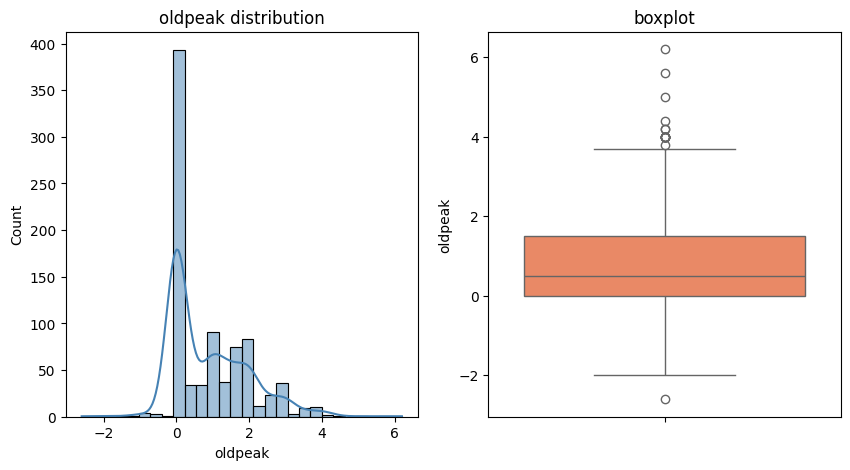

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df['oldpeak'], color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('oldpeak distribution')
print(f'mean: {df['oldpeak'].mean()}')

sns.boxplot(df['oldpeak'], color='coral', ax=axes[1])
axes[1].set_title('boxplot')

print(f'missing oldpeak count: {df['oldpeak'].isnull().sum()}')
print(f'Percentage of missing oldpeak values is: {df['oldpeak'].isnull().sum() / len(df['oldpeak']) * 100:.2f}%')


### slope: the slope of the peak exercise ST segment - Cat
### ca: number of major vessels (0-3) colored by fluoroscopy - Num (in num 0, 1, 2, 3)
### thal: [normal; fixed defect; reversible defect] - Cat

<StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
missing slope count: 309
Percentage of missing slope values is: 33.62%
[ 0.  3.  2.  1. nan]
missing ca count: 610
Percentage of missing ca values is: 66.38%
<StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str
missing thal count: 485
Percentage of missing thal values is: 52.77%


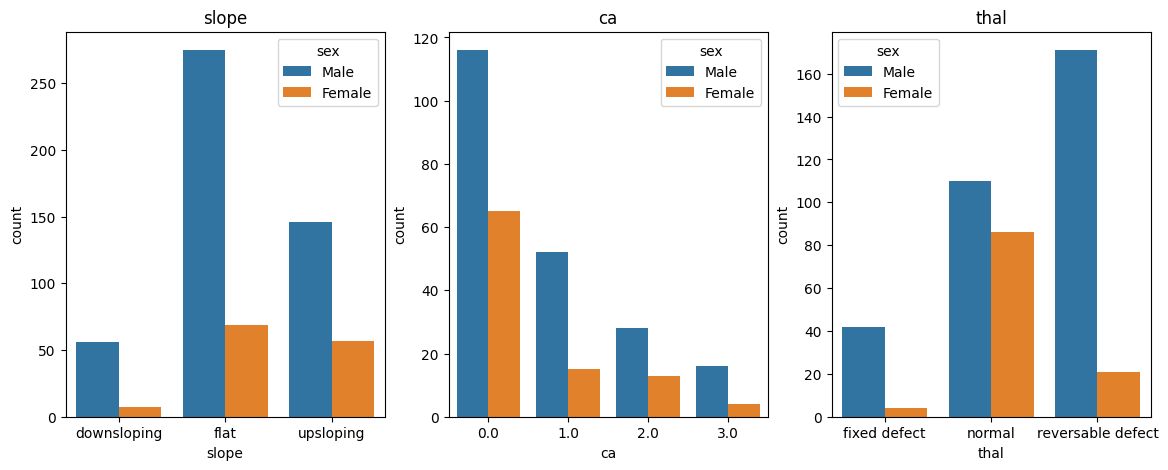

In [98]:
last_3_cols = ['slope','ca', 'thal']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(last_3_cols):
    print(df[col].unique())
    sns.countplot(df, x=col, hue='sex' , ax=axes[i])
    axes[i].set_title(col)
    print(f'missing {col} count: {df[col].isnull().sum()}')
    print(f'Percentage of missing {col} values is: {df[col].isnull().sum() / len(df[col]) * 100:.2f}%')

### num: the predicted attribute - Target
We will use this column to predict the heart disease. The unique values in this column are: [0,1,2,3,4], which states that there are 5 types of heart diseases.

0 = no heart disease.

1 = Mild Heart Disease types.

2 = Moderate Heart Disease type.

3 =  Severe Heart Disease type.

4 =  Critical Heart Disease type.


Text(0.5, 1.0, 'Target')

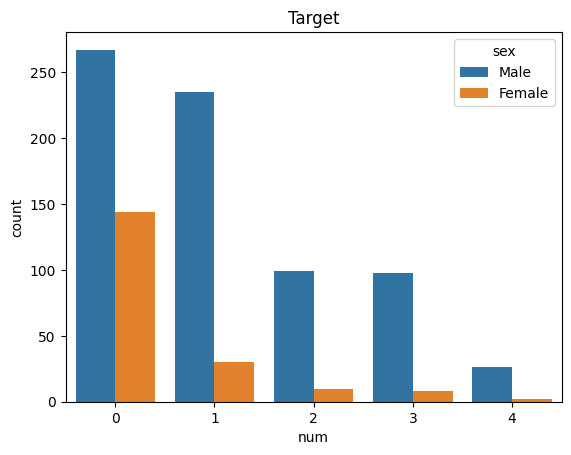

In [99]:

sns.countplot(df, x='num', hue='sex' )
plt.title('Target')

# 2. Data Preprocessing and transforming
- Handle missing values
- Categorical variables
- Feature scaling

### Handle missing values

In [106]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
print("Numerical missing values:")
print(df[num_cols].isnull().sum().sort_values(ascending=False))
num_cols_missing = df[num_cols].isnull().sum()[df.isnull().sum()>0].index.tolist()
print(f"Numerical missing  cols: {num_cols_missing}")

print("\nCategorical missing values:")
print(df[cat_cols].isnull().sum().sort_values(ascending=False))
cat_cols_missing = df[cat_cols].isnull().sum()[df.isnull().sum()>0].index.tolist()
print(f"nCategorical missing  cols: {cat_cols_missing}")

Numerical missing values:
id          0
age         0
trestbps    0
chol        0
thalch      0
oldpeak     0
ca          0
num         0
dtype: int64
Numerical missing  cols: []

Categorical missing values:
sex        0
dataset    0
cp         0
fbs        0
restecg    0
exang      0
slope      0
thal       0
dtype: int64
nCategorical missing  cols: []


In [107]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# remove outliers for low trestbps
print((df['trestbps'] < 80).sum())  # shows how many rows have trestbps < 80
df = df[(df['trestbps']>=80)  | (df['trestbps'].isna())]
print(len(df['trestbps']))

# handle numerical cols with missing data
num_cols_missing = ['trestbps', 'chol']
# Remove 6.4% missing values
imputer1 = IterativeImputer(max_iter=10, random_state=42)
imputer1.fit(df[['trestbps']])
df['trestbps'] = imputer1.transform(df[['trestbps']])
print(f"Missing values in trestbps column: {df['trestbps'].isnull().sum()}")
df.info()


# imputer2 = IterativeImputer(max_iter=10, random_state=42)
# df['chol'] = imputer2.fit_transform(df[['chol']])


0
919
Missing values in trestbps column: 0
<class 'pandas.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    str    
 3   dataset   919 non-null    str    
 4   cp        919 non-null    str    
 5   trestbps  919 non-null    float64
 6   chol      919 non-null    float64
 7   fbs       919 non-null    object 
 8   restecg   919 non-null    str    
 9   thalch    919 non-null    float64
 10  exang     919 non-null    object 
 11  oldpeak   919 non-null    float64
 12  slope     919 non-null    str    
 13  ca        919 non-null    float64
 14  thal      919 non-null    str    
 15  num       919 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 122.1+ KB


This function imputes missing values in Categorical columns

- 1: Separate rows with missing and non-missing values for the target column
- 2: Extract features (X) and target variable (y) for non-missing values
- 3: Extract other missing columns for later imputation
- 4: Encode categorical columns using LabelEncoder
- 5: Encode the target column if it is a boolean type
- 6: Initialize IterativeImputer with RandomForestRegressor as the estimator
- 7: Impute other missing columns in the dataset
- 8: Split the data into training and testing sets
- 9: Train a RandomForestClassifier to predict missing values in the target column
- 10: Predict missing values and calculate accuracy
- 11: Prepare the dataset with missing values for the final imputation
- 12: Impute missing values in the target column for the original missing data
- 13: Predict missing values in the target column
- 14: Combine the imputed data with the original dataset

This function imputes missing values in continuous columns

- 1: Separate rows with missing and non-missing values for the target column
- 2: Extract features (X) and target variable (y) for non-missing values
- 3: Extract other missing columns for later imputation
- 4: Encode categorical columns using LabelEncoder
- 5:Initialize IterativeImputer with RandomForestRegressor as the estimator
- 6: Impute other missing columns in the dataset
- 7: Split the data into training and testing sets
- 8: Train a RandomForestRegressor to predict missing values in the target column
- 9: Predict missing values and calculate performance metrics

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score, mean_squared_error

df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']


def safe_label_encode(series):
    """Label-encode a column while leaving NaN values as NaN."""
    le = LabelEncoder()
    not_null = series[series.notnull()]
    le.fit(not_null)
    encoded = pd.Series(np.nan, index=series.index, dtype=float)
    encoded[series.notnull()] = le.transform(not_null)
    return encoded


# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = safe_label_encode(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=False)

    if X[other_missing_cols].isnull().sum().sum() > 0:
        X[other_missing_cols] = iterative_imputer.fit_transform(X[other_missing_cols])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = safe_label_encode(X[col])

    if X[other_missing_cols].isnull().sum().sum() > 0:
        X[other_missing_cols] = iterative_imputer.transform(X[other_missing_cols])
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = safe_label_encode(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=False)

    if X[other_missing_cols].isnull().sum().sum() > 0:
        X[other_missing_cols] = iterative_imputer.fit_transform(X[other_missing_cols])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", np.sqrt(mean_absolute_error(y_test, y_pred)), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = safe_label_encode(X[col])

    if X[other_missing_cols].isnull().sum().sum() > 0:
        X[other_missing_cols] = iterative_imputer.transform(X[other_missing_cols])
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

In [109]:
# remove warning
import warnings
warnings.filterwarnings('ignore')
# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass

In [110]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [111]:
# Feature Engineering

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
binary_cols = ['sex','exang', 'fbs'] # label Encoder doesn't work in pipeline, so use ordinal
onehot_cols = ['thal', 'restecg', 'cp']
ordinal_cols = ['slope']
numeric_columns = ['oldpeak','ca', 'thalch', 'chol', 'trestbps', 'age']

slope_order = [['downsloping', 'flat', 'upsloping']]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_columns),
    # ('binary', LabelEncoder(), binary_cols), # LabelEncoder won't work here
    ('binary', OrdinalEncoder(), binary_cols),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=slope_order), ordinal_cols)
])

# 3. Model selection / training / prediction
- split data
- use logistic regression model for training
- predict on test data

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
y = df['num']
X = df.drop(columns=['num'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, 
                                                      stratify=y)

print(y_train.value_counts()) 
print(y_test.value_counts())
print(y_train.value_counts(normalize=True) * 100)  # % of each class in training data

pipe_lr = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)

mask = (y_test == 4)
print(np.unique(y_pred[mask], return_counts=True))

num
0    329
1    212
2     87
3     85
4     22
Name: count, dtype: int64
num
0    82
1    53
2    22
3    21
4     6
Name: count, dtype: int64
num
0    44.761905
1    28.843537
2    11.836735
3    11.564626
4     2.993197
Name: proportion, dtype: float64
(array([3, 4]), array([2, 4]))


# 4. Evaluation
- accuracy
- precision
- recall
- f1 score
- ROC-AUC

Accuracy: 0.5652
              precision    recall  f1-score   support

           0       0.89      0.80      0.85        82
           1       0.51      0.43      0.47        53
           2       0.32      0.27      0.29        22
           3       0.20      0.24      0.22        21
           4       0.19      0.67      0.30         6

    accuracy                           0.57       184
   macro avg       0.42      0.48      0.42       184
weighted avg       0.61      0.57      0.58       184



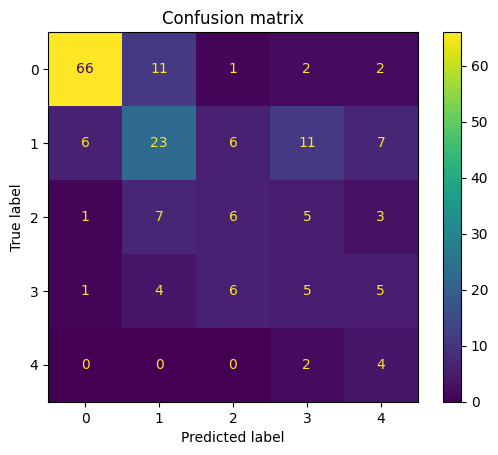

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
acc = accuracy_score(y_test, y_pred)


# rec = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
# print("Recall:", round(rec,4))
# print("F1:", round(f1,4))

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()

# Trying out other models

In [126]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score

models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('KNeighbors Classifier', KNeighborsClassifier()),
    ('Decision Tree Classifier', DecisionTreeClassifier(random_state=42)),
    ('AdaBoost Classifier', AdaBoostClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('XGboost Classifier', XGBClassifier(random_state=42)),   
    
    ('Support Vector Machine', SVC(random_state=42)),
    
    ('Naye base Classifier', GaussianNB())
    
    
]

best_model = None
best_accuracy = 0.0

for name, model in models:
    pipeline = Pipeline([
        ('pre', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    mean_accuracy = scores.mean()
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
     #print the performance metrics
    print("Model", name)
    print("Cross Validation accuracy: ", mean_accuracy)
    print("Test Accuracy: ", accuracy)
    print()
    
    #Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline
        
        
print("Best Model: ", best_model)

    
    

Model Logistic Regression
Cross Validation accuracy:  0.6108843537414966
Test Accuracy:  0.625

Model Gradient Boosting
Cross Validation accuracy:  0.6462585034013605
Test Accuracy:  0.6141304347826086

Model KNeighbors Classifier
Cross Validation accuracy:  0.5891156462585034
Test Accuracy:  0.6467391304347826

Model Decision Tree Classifier
Cross Validation accuracy:  0.5482993197278911
Test Accuracy:  0.5760869565217391

Model AdaBoost Classifier
Cross Validation accuracy:  0.5836734693877551
Test Accuracy:  0.6141304347826086

Model Random Forest
Cross Validation accuracy:  0.6408163265306122
Test Accuracy:  0.6467391304347826

Model XGboost Classifier
Cross Validation accuracy:  0.6244897959183673
Test Accuracy:  0.6086956521739131

Model Support Vector Machine
Cross Validation accuracy:  0.6312925170068027
Test Accuracy:  0.6467391304347826

Model Naye base Classifier
Cross Validation accuracy:  0.3374149659863946
Test Accuracy:  0.3695652173913043

Best Model:  Pipeline(steps=[(